In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score
import joblib

In [ ]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

dataset = "bhautikvekariya21/air-quality-dataset-indian-cities-2022-2025"

# File 1
df1 = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    dataset,
    "aqi_india_38cols_knn_final.csv"
)

print("Columns in aqi_india_38cols_knn_final.csv:")
print(df1.columns)
print("\n")

# File 2
df2 = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    dataset,
    "INDIA_AQI_COMPLETE_20251126.csv"
)

print("Columns in INDIA_AQI_COMPLETE_20251126.csv:")
print(df2.columns)

100%|██████████| 169M/169M [00:03<00:00, 53.6MB/s]


Columns in aqi_india_38cols_knn_final.csv:
Index(['city', 'state', 'latitude', 'longitude', 'datetime', 'month',
       'day_name', 'is_weekend', 'season', 'time_of_day', 'humidity_percent',
       'dew_point_c', 'wind_gusts_kmh', 'precipitation_mm', 'is_raining',
       'heavy_rain', 'pressure_msl_hpa', 'cloud_cover_percent', 'pm2_5_ugm3',
       'pm10_ugm3', 'co_ugm3', 'no2_ugm3', 'so2_ugm3', 'o3_ugm3', 'dust_ugm3',
       'aod', 'us_aqi', 'aqi_category', 'pm25_category_india',
       'festival_period', 'crop_burning_season'],
      dtype='object')




100%|██████████| 270M/270M [00:05<00:00, 54.4MB/s]


Columns in INDIA_AQI_COMPLETE_20251126.csv:
Index(['City', 'State', 'Latitude', 'Longitude', 'Datetime', 'Year', 'Month',
       'Day', 'Hour', 'Day_of_Week', 'Day_Name', 'Week_of_Year', 'Is_Weekend',
       'Quarter', 'Season', 'Time_of_Day', 'Temp_2m_C', 'Temp_80m_C',
       'Temp_120m_C', 'Temp_180m_C', 'Humidity_Percent', 'Dew_Point_C',
       'Humidity_Category', 'Wind_Speed_10m_kmh', 'Wind_Speed_80m_kmh',
       'Wind_Speed_120m_kmh', 'Wind_Dir_10m', 'Wind_Gusts_kmh',
       'Wind_Category', 'Wind_Stagnation', 'Precipitation_mm', 'Rain_mm',
       'Is_Raining', 'Heavy_Rain', 'Pressure_MSL_hPa', 'Surface_Pressure_hPa',
       'Solar_Radiation_Wm2', 'Direct_Radiation_Wm2', 'Diffuse_Radiation_Wm2',
       'UV_Index', 'Cloud_Cover_Percent', 'Cloud_Low_Percent',
       'Cloud_Mid_Percent', 'Cloud_High_Percent', 'Is_Daytime',
       'Sunshine_Seconds', 'PM2_5_ugm3', 'PM10_ugm3', 'PM_Ratio', 'CO_ugm3',
       'NO2_ugm3', 'SO2_ugm3', 'O3_ugm3', 'Dust_ugm3', 'NH3_ugm3', 'AOD',
       'US_

In [ ]:
required_features = [
    'Latitude', 'Longitude', 'Temp_2m_C', 'Humidity_Percent',
    'SO2_ugm3', 'NO2_ugm3', 'CO_ugm3', 'Wind_Speed_10m_kmh', 'Dust_ugm3'
]
target = 'US_AQI'

df_model = df2[required_features + [target]].dropna()

X = df_model[required_features]
y = df_model[target]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
# Before training: Take the log of the target
y_train_log = np.log1p(y_train)

# Train the model on the logged values
model.fit(X_train_scaled, y_train_log)

# When predicting: Use 'exp' to bring it back to normal scale
y_pred_log = model.predict(X_test_scaled)
y_pred = np.expm1(y_pred_log)

In [ ]:
print("--- Log-Transformed Model Performance ---")
print(f"Accuracy (R2 Score): {r2_score(y_test, y_pred):.4f}")
print(f"Average Error (MAE): {mean_absolute_error(y_test, y_pred):.2f} AQI points")

--- Log-Transformed Model Performance ---
Accuracy (R2 Score): 0.8012
Average Error (MAE): 14.07 AQI points


In [ ]:
def predict_aqi_now(lat, lon, temp, hum, so2, no2, co, wind, dust):
    # 1. Prepare input
    user_input = np.array([[lat, lon, temp, hum, so2, no2, co, wind, dust]])
    user_scaled = scaler.transform(user_input)

    # 2. Predict (This gives the LOG value)
    prediction_log = model.predict(user_scaled)[0]

    # 3. CONVERT BACK (This gives the actual AQI)
    prediction = np.expm1(prediction_log)

    # 4. Categorize using the actual AQI
    if prediction <= 50: status = "Good"
    elif prediction <= 100: status = "Moderate"
    elif prediction <= 150: status = "Unhealthy for Sensitive Groups"
    elif prediction <= 200: status = "Unhealthy"
    elif prediction <= 300: status = "Very Unhealthy"
    else: status = "Hazardous"

    return round(prediction, 2), status

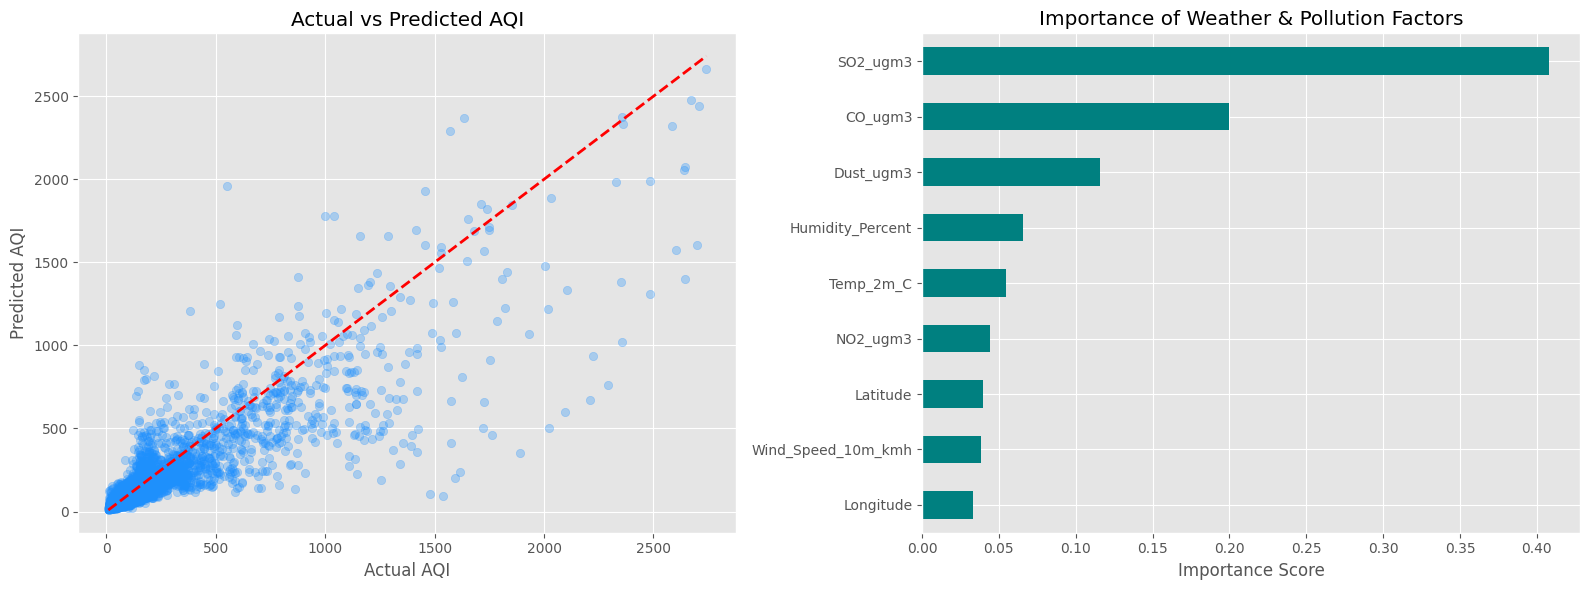

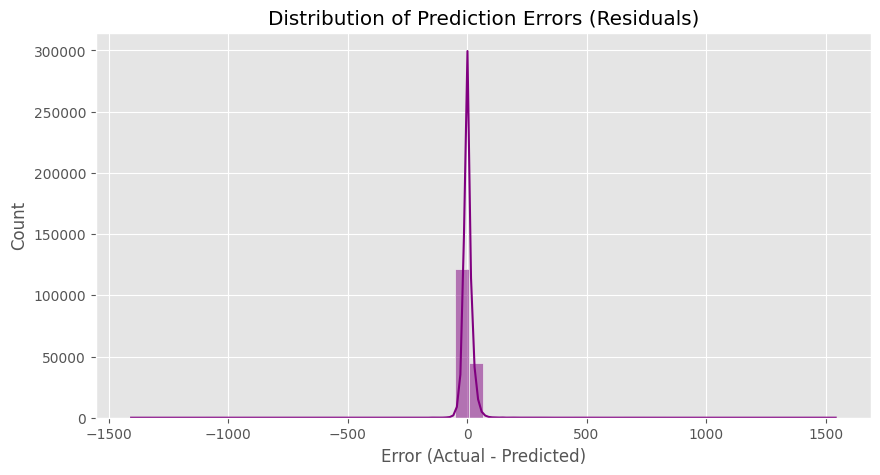

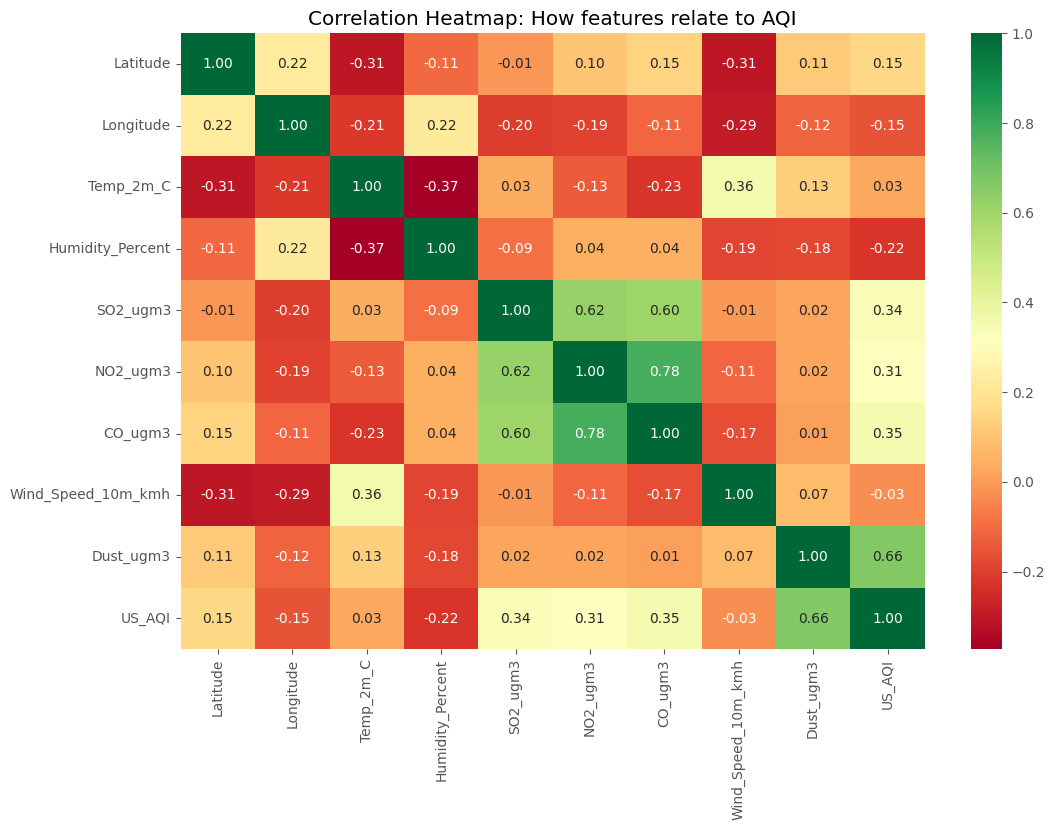

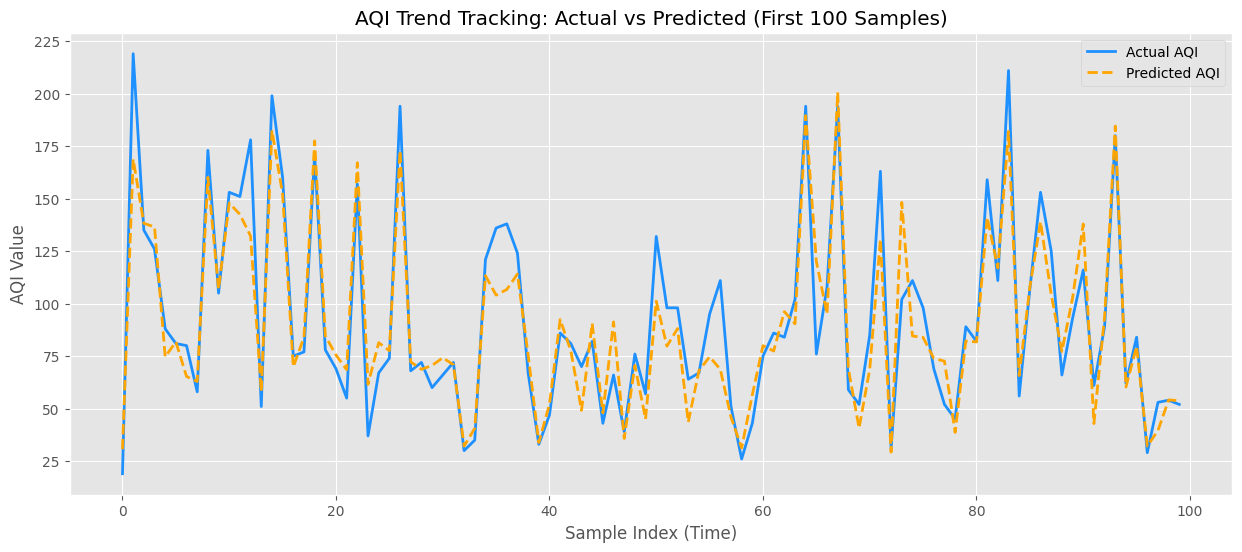

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('ggplot')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Actual vs Predicted Scatter Plot
ax1.scatter(y_test, y_pred, alpha=0.3, color='dodgerblue')
ax1.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2) # Diagonal line
ax1.set_title('Actual vs Predicted AQI')
ax1.set_xlabel('Actual AQI')
ax1.set_ylabel('Predicted AQI')

# Feature Importance
importances = model.feature_importances_
features = X_train.columns
feat_importances = pd.Series(importances, index=features).sort_values(ascending=True)
feat_importances.plot(kind='barh', color='teal', ax=ax2)
ax2.set_title('Importance of Weather & Pollution Factors')
ax2.set_xlabel('Importance Score')

plt.tight_layout()
plt.show()

#  Error Distribution
plt.figure(figsize=(10, 5))
sns.histplot(y_test - y_pred, bins=50, kde=True, color='purple')
plt.title('Distribution of Prediction Errors (Residuals)')
plt.xlabel('Error (Actual - Predicted)')
plt.show()

# Correlation Heatmap
plt.figure(figsize=(12, 8))
# Use the cleaned dataframe with only your selected features
correlation_matrix = df_model.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='RdYlGn', fmt=".2f")
plt.title('Correlation Heatmap: How features relate to AQI')
plt.show()


# Line chart for the first 100 samples to show trend tracking
plt.figure(figsize=(15, 6))
plt.plot(y_test.values[:100], label='Actual AQI', color='dodgerblue', linewidth=2)
plt.plot(y_pred[:100], label='Predicted AQI', color='orange', linestyle='--', linewidth=2)
plt.title('AQI Trend Tracking: Actual vs Predicted (First 100 Samples)')
plt.xlabel('Sample Index (Time)')
plt.ylabel('AQI Value')
plt.legend()
plt.show()

In [ ]:
import joblib
from google.colab import drive
drive.mount('/content/drive')


joblib.dump(model, '/content/drive/MyDrive/aqi_model.pkl', compress=3)
joblib.dump(scaler, '/content/drive/MyDrive/scaler.pkl', compress=3)

print("Saved to Google Drive!")


Mounted at /content/drive
Saved to Google Drive!
